# 02e — Diseño de Agentes Inteligentes

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02e-agentes.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Aquí unimos
> todos los conceptos anteriores: prompts, herramientas, memoria y
> orquestación para construir agentes autónomos.

In [1]:
!pip install -q langchain langchain-openai langchain-community python-dotenv langgraph

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from langchain_openai import ChatOpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    llm = ChatOpenAI(model="gemma4:e2b-mlx", base_url=LLM_URL, api_key=LLM_KEY, temperature=0)
    print("✅ ChatOpenAI configurado. Las celdas de ejemplo funcionarán correctamente.")

✅ ChatOpenAI configurado. Las celdas de ejemplo funcionarán correctamente.

## Diseño de Agentes Inteligentes

### ¿Qué es un agente?

Un **agente** es un sistema que combina un LLM con un conjunto de
herramientas y un **bucle de decisión autónomo**. La diferencia clave
con un simple chatbot es:

| Chatbot                      | Agente                                       |
|------------------------------------|------------------------------------|
| LLM responde con lo que sabe | LLM decide **si necesita** usar herramientas |
| Sin acceso a datos externos  | Busca en BBDD, APIs, archivos, calcula…      |
| Un solo turno                | Múltiples pasos hasta resolver la tarea      |
| Sin planificación            | Planifica, ejecuta, observa, corrige         |

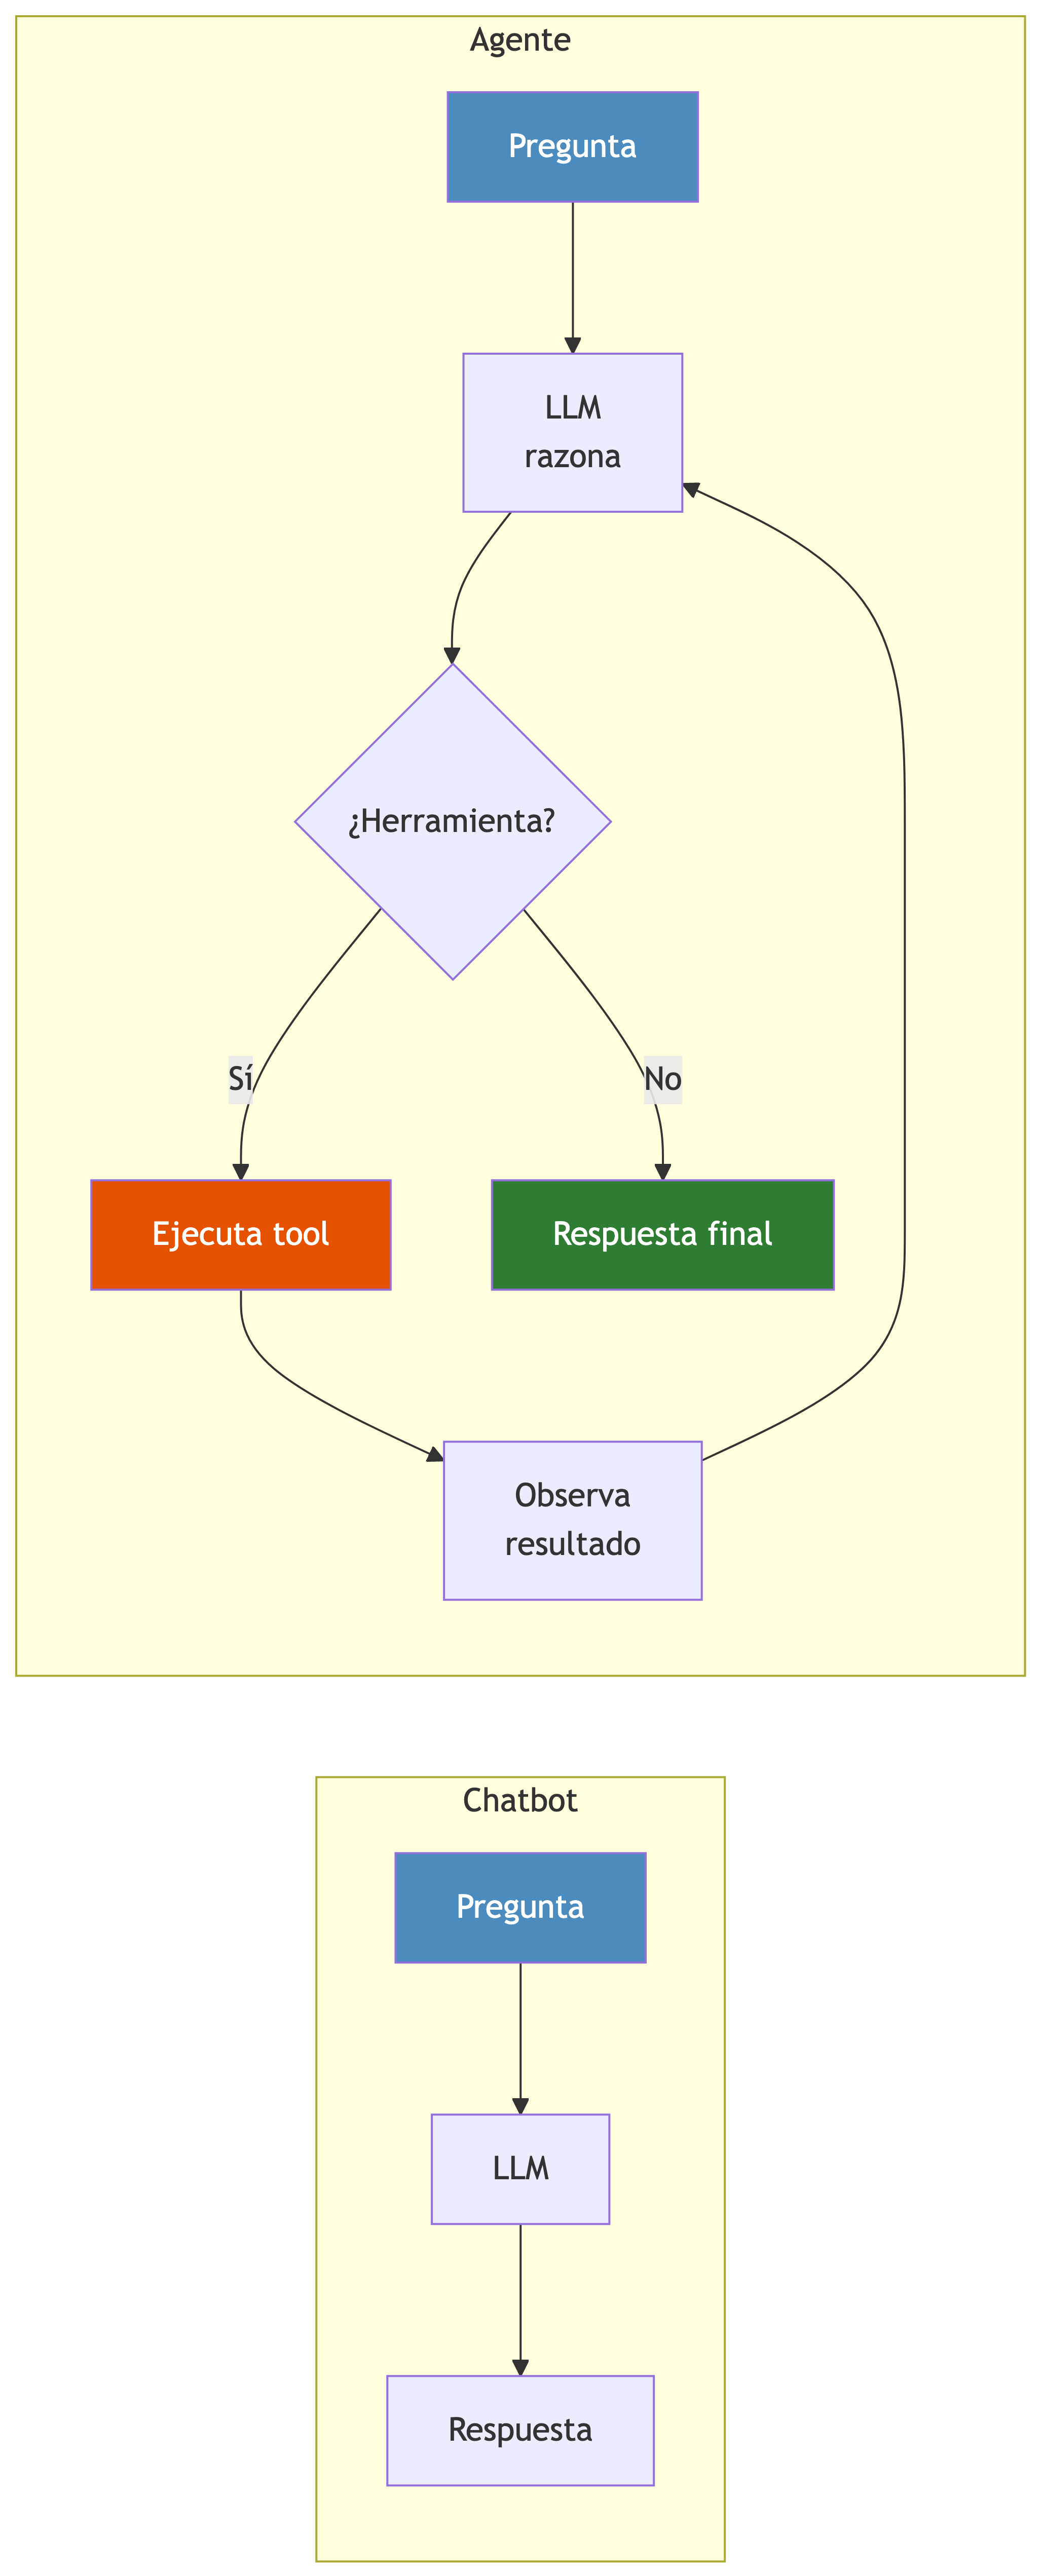

### El patrón ReAct (Reasoning + Acting)

**ReAct** es el patrón de diseño de agentes más popular. El LLM alterna
entre: - **Reasoning (razonar):** escribir un plan o pensamiento en
lenguaje natural - **Acting (actuar):** invocar una herramienta con
parámetros concretos - **Observation (observar):** recibir el resultado
de la herramienta y decidir el siguiente paso

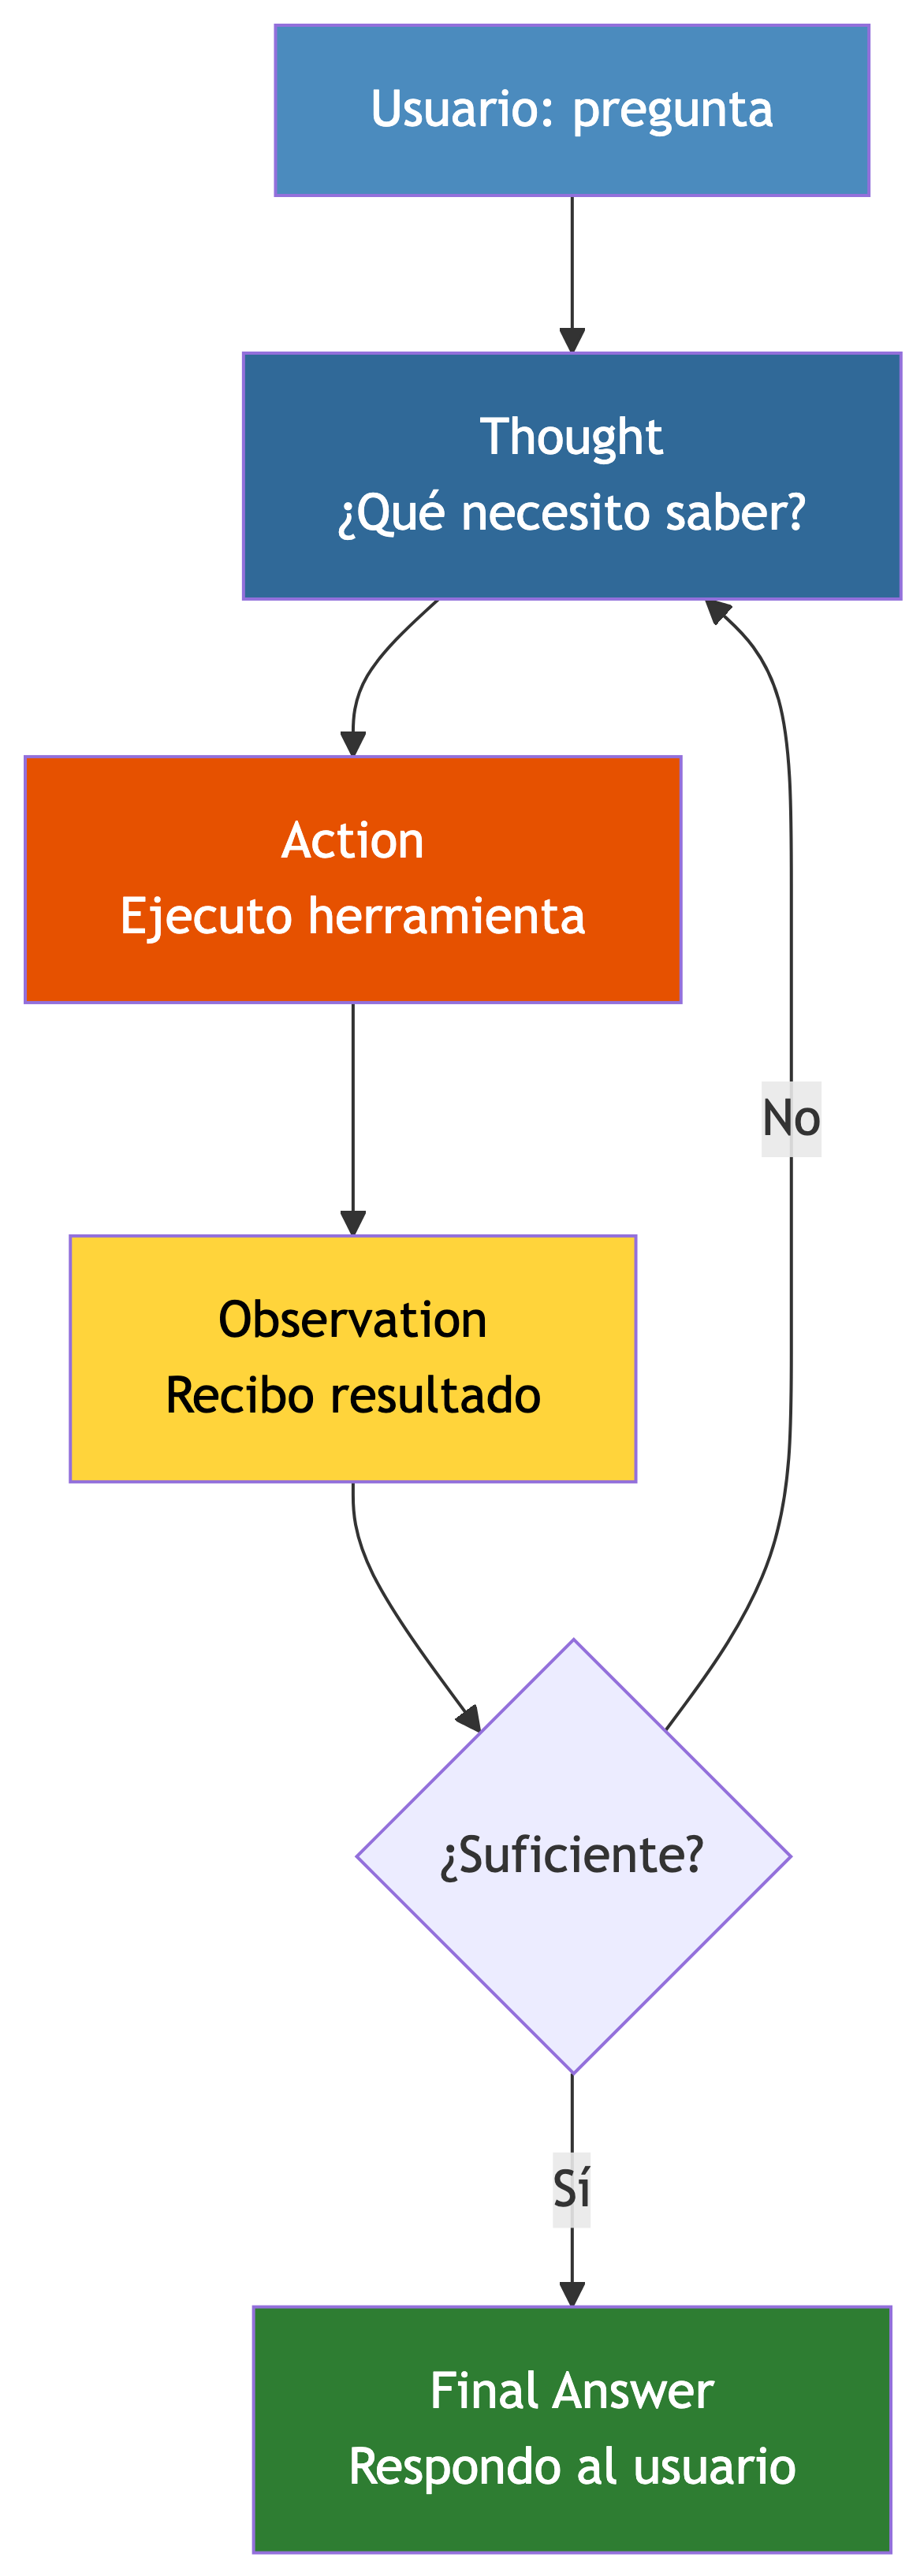

### Tool Calling (Function Calling nativo)

LangChain abstrae el bucle ReAct con `create_agent`:

In [4]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def calculadora(expresion: str) -> str:
    """Evalúa una expresión matemática. Ejemplo: '2 + 2 * 3'."""
    try:
        resultado = eval(expresion, {"__builtins__": {}}, {})
        return f"Resultado: {resultado}"
    except Exception as e:
        return f"Error: {e}"

@tool
def buscar_cliente(nombre: str) -> str:
    """Busca datos de un cliente por nombre en la base de datos corporativa. Ejemplo: buscar_cliente('acme')."""
    clientes = {
        "acme": "ACME Corp: sector tecnología, 500 empleados, cliente desde 2020, facturación 150k€/año",
        "ibertech": "IberTech SA: sector industrial, 1200 empleados, cliente desde 2018, facturación 450k€/año",
        "datafy": "Datafy Analytics: sector consultoría, 50 empleados, cliente desde 2023, facturación 80k€/año"
    }
    nombre_lower = nombre.lower()
    for clave, datos in clientes.items():
        if clave in nombre_lower:
            return datos
    return f"Cliente '{nombre}' no encontrado. Clientes disponibles: {', '.join(clientes.keys())}"

@tool
def convertir_moneda(cantidad: float, de: str, a: str) -> str:
    """Convierte una cantidad de una moneda a otra. Monedas soportadas: EUR, USD, GBP, JPY."""
    tasas = {"EUR": 1.0, "USD": 1.08, "GBP": 0.85, "JPY": 160.0}
    if de not in tasas or a not in tasas:
        return f"Moneda no soportada '{de}' o '{a}'. Usa: EUR, USD, GBP, JPY"
    resultado = cantidad / tasas[de] * tasas[a]
    return f"{cantidad} {de} = {resultado:.2f} {a}"

# Probar las herramientas directamente (sin LLM)
print("=== Probando herramientas sin LLM ===")
print(calculadora.invoke({"expresion": "15 * 42"}))
print(buscar_cliente.invoke({"nombre": "datafy"}))
print(convertir_moneda.invoke({"cantidad": 100, "de": "EUR", "a": "USD"}))

if not LLM_KEY:
    print("\n⚠️  Configura LLM_API_KEY en .env para ver el agente en acción.")
else:
    tools = [calculadora, buscar_cliente, convertir_moneda]
    agente = create_agent(
        model=llm,
        tools=tools,
        system_prompt="Eres un asistente corporativo con acceso a herramientas. Responde de forma concisa.",
    )

    preguntas = [
        "¿Cuánto factura ACME Corp en dólares?",
        "¿Cuál es el 15% de la facturación anual de IberTech?",
        "Busca datos de Datafy y convierte su facturación a libras esterlinas"
    ]

    for pregunta in preguntas:
        print(f"\n{'='*60}")
        print(f"PREGUNTA: {pregunta}")
        try:
            result = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
            print(f"RESPUESTA: {result['messages'][-1].content}")
        except Exception as e:
            print(f"ERROR: {e}")

=== Probando herramientas sin LLM ===
Resultado: 630
Datafy Analytics: sector consultoría, 50 empleados, cliente desde 2023, facturación 80k€/año
100.0 EUR = 108.00 USD

PREGUNTA: ¿Cuánto factura ACME Corp en dólares?
RESPUESTA: ACME Corp factura 150,000 EUR al año, lo que equivale a aproximadamente 172,463.15 USD.

PREGUNTA: ¿Cuál es el 15% de la facturación anual de IberTech?
RESPUESTA: El 15% de la facturación anual de IberTech es 60,000.

PREGUNTA: Busca datos de Datafy y convierte su facturación a libras esterlinas
RESPUESTA: Por favor, especifique el nombre del cliente que desea buscar y la cantidad y las monedas que desea convertir.

### Cómo definir una buena herramienta

El secreto de un agente que funciona está en cómo describes las
herramientas:

In [5]:
# ❌ MAL — descripción vaga
@tool
def consultar(query: str) -> str:
    """Consulta algo."""
    return f"Resultado para: {query}"

# ✅ BIEN — descripción precisa, con tipos claros
@tool
def consultar_ventas_por_mes(mes: int, anio: int) -> str:
    """
    Consulta las ventas totales de un mes concreto.

    Args:
        mes: número del mes (1=Enero ... 12=Diciembre)
        anio: año de la consulta (ej: 2025)

    Returns:
        String con el total de ventas del mes o mensaje de error si no hay datos.

    Ejemplo: consultar_ventas_por_mes(3, 2025) → 'Marzo 2025: 245.600€'
    """
    ventas_2025 = {1: 380000, 2: 410000, 3: 430000, 4: 395000}
    if anio == 2025 and 1 <= mes <= 12:
        total = ventas_2025.get(mes, "sin datos")
        return f"{mes}/{anio}: {total}€"
    return "No hay datos para esa fecha."

# Mostrar la diferencia en las descripciones que ve el LLM
print("Descripción de 'consultar' (❌ MAL):")
print(repr(consultar.name + ": " + consultar.description))
print("\nDescripción de 'consultar_ventas_por_mes' (✅ BIEN):")
print(repr(consultar_ventas_por_mes.name + ": " + consultar_ventas_por_mes.description))

Descripción de 'consultar' (❌ MAL):
'consultar: Consulta algo.'

Descripción de 'consultar_ventas_por_mes' (✅ BIEN):
"consultar_ventas_por_mes: Consulta las ventas totales de un mes concreto.\n\nArgs:\n    mes: número del mes (1=Enero ... 12=Diciembre)\n    anio: año de la consulta (ej: 2025)\n\nReturns:\n    String con el total de ventas del mes o mensaje de error si no hay datos.\n\nEjemplo: consultar_ventas_por_mes(3, 2025) → 'Marzo 2025: 245.600€'"

> **Reglas para diseñar herramientas**
>
> 1.  **Docstring detallado**: qué hace, qué parámetros recibe, qué
>     devuelve, un ejemplo
> 2.  **Una responsabilidad**: cada tool hace una cosa y la hace bien
> 3.  **Manejo de errores explícito**: siempre devuelve texto
>     descriptivo, nunca excepciones crudas
> 4.  **Tipos concretos en parámetros**: `mes: int`, no `fecha: str` (el
>     LLM elegirá mejor)
> 5.  **Idempotencia cuando sea posible**: misma entrada → misma salida

### Pipeline RAG Supervisado con LangGraph

LangGraph permite construir flujos complejos donde el LLM decide qué
hacer en cada paso. En este ejemplo, un **supervisor** recibe una
pregunta sobre productos y decide si consultar una base de datos SQL,
buscar en informes trimestrales (Chroma), o ambas fuentes. Luego un
generador produce la respuesta final con el contexto recuperado.

In [6]:
import sqlite3, chromadb
from sentence_transformers import SentenceTransformer

# --- BD SQLite con productos ---
db = sqlite3.connect(":memory:")
db.execute("CREATE TABLE productos (id INTEGER, nombre TEXT, categoria TEXT, precio REAL, stock INTEGER)")
db.executemany("INSERT INTO productos VALUES (?, ?, ?, ?, ?)", [
    (1, "Monitor 4K", "Electrónica", 349.0, 50),
    (2, "NovaBuds Pro", "Electrónica", 89.0, 120),
    (3, "Silla Ergonómica", "Hogar", 249.0, 15),
    (4, "Lámpara LED Smart", "Hogar", 49.0, 30),
    (5, "Bicicleta Eléctrica", "Deportes", 899.0, 8),
])

# --- Chroma con informes trimestrales ---
model_st = SentenceTransformer("all-MiniLM-L6-v2")
client_c = chromadb.EphemeralClient()
col = client_c.create_collection("informes")
informes = [
    "El Monitor 4K lideró las ventas del Q1 con un margen del 42%. La demanda sigue alta.",
    "NovaBuds Pro tuvo un crecimiento del 18% en Q2. Es el producto más vendido de Electrónica.",
    "La Silla Ergonómica agotó stock en Q3. Se recomienda reposición urgente antes de fin de año.",
    "La Bicicleta Eléctrica ralentizó su crecimiento por problemas en la cadena de suministro.",
]
for i, txt in enumerate(informes):
    emb = model_st.encode(txt).tolist()
    col.add(ids=[f"doc_{i}"], embeddings=[emb], documents=[txt])

print(f"✅ BD: {db.execute('SELECT COUNT(*) FROM productos').fetchone()[0]} productos")
print(f"✅ Chroma: {col.count()} informes")

✅ BD: 5 productos
✅ Chroma: 4 informes

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage, HumanMessage

class EstadoRAG(TypedDict):
    pregunta: str
    ruta: str          # "sql", "pdf" o "ambos"
    resultado_sql: str
    resultado_pdf: str
    respuesta: str

def supervisor(state: EstadoRAG) -> EstadoRAG:
    """El LLM decide qué fuente(s) consultar."""
    prompt = (
        f"Pregunta: {state['pregunta']}\n\n"
        "¿Qué fuente necesitas? Responde solo: sql, pdf o ambos\n"
        "- sql: si habla de precios, stock, categorías (datos concretos)\n"
        "- pdf: si habla de tendencias, informes, análisis\n"
        "- ambos: si necesita datos + informes"
    )
    resp = llm.invoke([HumanMessage(content=prompt)])
    ruta = resp.content.strip().lower()
    state["ruta"] = ruta if ruta in ("sql", "pdf", "ambos") else "sql"
    return state

def ejecutar(state: EstadoRAG) -> EstadoRAG:
    """Ejecuta las consultas según la ruta decidida."""
    p = state["pregunta"].lower()

    if state["ruta"] in ("sql", "ambos"):
        if "precio" in p or "caro" in p or "barato" in p:
            filas = db.execute("SELECT nombre, precio FROM productos ORDER BY precio DESC").fetchall()
            state["resultado_sql"] = "\n".join(f"  {r[0]}: {r[1]}€" for r in filas)
        elif "stock" in p or "unidade" in p or "quedan" in p:
            filas = db.execute("SELECT nombre, stock FROM productos WHERE stock < 30").fetchall()
            state["resultado_sql"] = "\n".join(f"  {r[0]}: {r[1]} uds." for r in filas) or "  Todos los productos tienen stock suficiente."
        else:
            filas = db.execute("SELECT nombre, categoria, precio, stock FROM productos").fetchall()
            state["resultado_sql"] = "\n".join(f"  {r[0]} ({r[1]}): {r[2]}€, {r[3]} uds." for r in filas)

    if state["ruta"] in ("pdf", "ambos"):
        emb = model_st.encode(state["pregunta"]).tolist()
        res = col.query(query_embeddings=[emb], n_results=2)
        state["resultado_pdf"] = "\n".join(res["documents"][0]) if res.get("documents") else "Sin resultados."

    return state

def generar(state: EstadoRAG) -> EstadoRAG:
    """Genera la respuesta final con el contexto recuperado."""
    contexto = ""
    if state["resultado_sql"]:
        contexto += f"Datos de productos:\n{state['resultado_sql']}\n\n"
    if state["resultado_pdf"]:
        contexto += f"Informes:\n{state['resultado_pdf']}\n\n"

    prompt = f"Contexto:\n{contexto}Pregunta: {state['pregunta']}\nResponde en español usando solo el contexto."
    resp = llm.invoke([HumanMessage(content=prompt)])
    state["respuesta"] = resp.content
    return state

# Construir el grafo
grafo = StateGraph(EstadoRAG)
grafo.add_node("supervisor", supervisor)
grafo.add_node("ejecutar", ejecutar)
grafo.add_node("generar", generar)

grafo.set_entry_point("supervisor")
grafo.add_edge("supervisor", "ejecutar")
grafo.add_edge("ejecutar", "generar")
grafo.add_edge("generar", END)

app = grafo.compile()
print("✅ Pipeline RAG Supervisado listo")

✅ Pipeline RAG Supervisado listo

In [8]:
preguntas_prueba = [
    "¿Qué productos tienen menos de 30 unidades en stock?",
    "¿Qué dice el informe sobre el Monitor 4K?",
    "¿Cuál es el producto más caro y qué se dice de él en los informes?",
]

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env")
else:
    for i, pregunta in enumerate(preguntas_prueba, 1):
        print(f"\n{'='*70}")
        print(f"PREGUNTA {i}: {pregunta}")
        print('='*70)
        result = app.invoke({"pregunta": pregunta, "ruta": "", "resultado_sql": "", "resultado_pdf": "", "respuesta": ""})
        print(f"Ruta elegida: {result['ruta']}")
        print(f"\nRESPUESTA: {result['respuesta']}")


PREGUNTA 1: ¿Qué productos tienen menos de 30 unidades en stock?
Ruta elegida: sql

RESPUESTA: La Silla Ergonómica y la Bicicleta Eléctrica tienen menos de 30 unidades en stock.

PREGUNTA 2: ¿Qué dice el informe sobre el Monitor 4K?
Ruta elegida: sql

RESPUESTA: El Monitor 4K tiene un precio de 349.0€ y hay 50 unidades.

PREGUNTA 3: ¿Cuál es el producto más caro y qué se dice de él en los informes?
Ruta elegida: ambos

RESPUESTA: El producto más caro es la Bicicleta Eléctrica (899.0€). Los informes no mencionan a este producto.

### Agentes síncronos vs asíncronos

| Característica | Síncrono | Asíncrono |
|------------------------|------------------------|------------------------|
| **Ejecución** | Un paso tras otro, bloqueante | Varios pasos en paralelo, no bloqueante |
| **Cuándo usarlo** | Tareas secuenciales | Herramientas independientes (buscar BD + API a la vez) |
| **Complejidad** | Simple de razonar | Necesita gestión de concurrencia |
| **Rendimiento** | Más lento si hay muchas tools | Más rápido con I/O (APIs, BBDD) |

In [9]:
import time, asyncio

@tool
def consulta_rapida(texto: str) -> str:
    """Simula una consulta rápida en base de datos."""
    time.sleep(0.5)
    return f"Resultado para '{texto}': 42"

# Versión síncrona
inicio = time.time()
r1 = consulta_rapida.invoke({"texto": "ventas enero"})
r2 = consulta_rapida.invoke({"texto": "ventas febrero"})
print(f"Síncrono: {time.time() - inicio:.2f}s → {r1}, {r2}")

Síncrono: 1.02s → Resultado para 'ventas enero': 42, Resultado para 'ventas febrero': 42

### Arquitecturas multi-agente

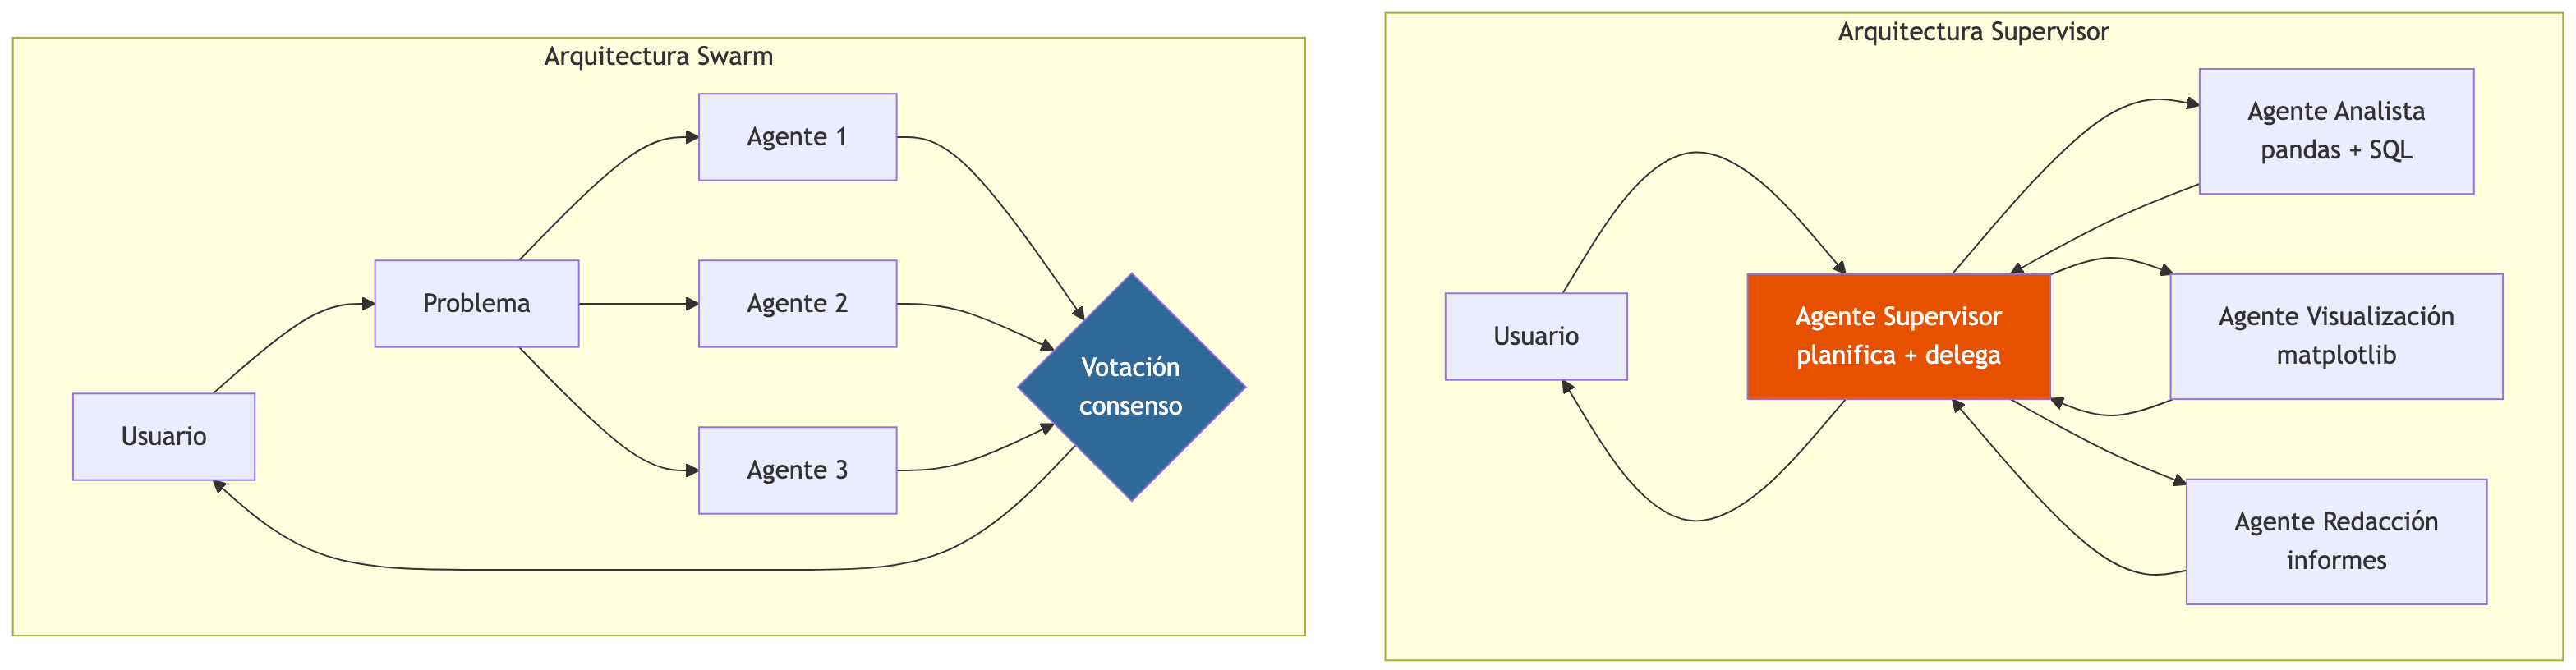

### Ejemplo final: agente analítico con pandas

Uniendo todos los conceptos, creamos un agente que analiza datos con
pandas:

In [10]:
import pandas as pd

# Datos de ejemplo (sin necesidad de archivo externo)
df = pd.DataFrame({
    "fecha": pd.date_range("2025-01-01", periods=20, freq="D"),
    "producto": ["A", "B", "A", "C", "B", "A", "C", "B", "A", "C"] * 2,
    "categoria": ["X", "Y", "X", "Y", "X", "Y", "X", "Y", "X", "Y"] * 2,
    "cantidad": [10, 5, 8, 12, 7, 9, 11, 6, 14, 3] * 2,
    "precio_unitario": [100, 200, 100, 150, 200, 100, 150, 200, 100, 150] * 2,
    "region": ["Madrid", "Barcelona", "Madrid", "Norte", "Barcelona", "Madrid", "Norte", "Barcelona", "Madrid", "Norte"] * 2
})
df["total"] = df["cantidad"] * df["precio_unitario"]

print("Dataset cargado:")
print(f"  Filas: {len(df)}, Columnas: {list(df.columns)}")
print(f"  Total ventas: {df['total'].sum():.0f}€")
print()
print(df.head(8).to_string())

@tool
def consulta_pandas(expresion: str) -> str:
    """
    Ejecuta una expresión de pandas sobre el DataFrame de ventas.
    El DataFrame 'df' tiene columnas: fecha, producto, categoria, cantidad, precio_unitario, total, region.

    Args:
        expresion: expresión Python usando 'df' (ej: "df.groupby('region')['total'].sum()")

    Returns:
        Resultado de la consulta como string.

    Ejemplo: consulta_pandas("df['total'].mean()") → 'Media de ventas: 4250.5'
    """
    try:
        resultado = eval(expresion, {"df": df, "pd": pd, "__builtins__": {}})
        return str(resultado)
    except Exception as e:
        return f"Error en consulta: {e}"

# Probar la herramienta directamente
print("=== Probando herramienta de consulta ===")
print("Ventas por región:")
print(consulta_pandas.invoke({"expresion": "df.groupby('region')['total'].sum()"}))
print("\nProducto más vendido (unidades):")
print(consulta_pandas.invoke({"expresion": "df.groupby('producto')['cantidad'].sum().idxmax()"}))

if LLM_KEY:
    SYSTEM_PROMPT = "Eres un analista de datos. Usa la herramienta consulta_pandas para responder preguntas sobre el DataFrame de ventas. Responde en español."
    agente = create_agent(model=llm, tools=[consulta_pandas], system_prompt=SYSTEM_PROMPT)

    print("\n" + "=" * 60)
    pregunta = "¿Cuál es la región con mayor facturación total y a cuánto asciende?"
    print(f"PREGUNTA: {pregunta}")
    result = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
    print(f"RESPUESTA: {result['messages'][-1].content}")

Dataset cargado:
  Filas: 20, Columnas: ['fecha', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'region', 'total']
  Total ventas: 23200€

       fecha producto categoria  cantidad  precio_unitario     region  total
0 2025-01-01        A         X        10              100     Madrid   1000
1 2025-01-02        B         Y         5              200  Barcelona   1000
2 2025-01-03        A         X         8              100     Madrid    800
3 2025-01-04        C         Y        12              150      Norte   1800
4 2025-01-05        B         X         7              200  Barcelona   1400
5 2025-01-06        A         Y         9              100     Madrid    900
6 2025-01-07        C         X        11              150      Norte   1650
7 2025-01-08        B         Y         6              200  Barcelona   1200
=== Probando herramienta de consulta ===
Ventas por región:
region
Barcelona    7200
Madrid       8200
Norte        7800
Name: total, dtype: int64

Producto m

### Cuándo usar un agente

> **No todo necesita un agente**
>
> Los agentes son potentes pero más caros (múltiples llamadas al LLM),
> más lentos y más impredecibles que una cadena simple. Usa un agente
> solo cuando:
>
> - ✅ La tarea requiere **decidir qué herramienta usar en tiempo real**
> - ✅ El número de pasos **no se conoce de antemano**
> - ✅ Necesitas **corregir errores** sobre la marcha (ReAct)
> - ❌ El flujo de trabajo es **fijo y conocido** (usa una cadena LCEL
>   simple)
> - ❌ La tarea es **determinista** (una función Python clásica es más
>   barata y fiable)

> **Lectura recomendada:** [LangChain
> Agents](https://python.langchain.com/docs/concepts/agents/)